# Fraud Detection – Model Training

This notebook implements the model training pipeline based on the reduced 
feature set prepared during the feature reduction stage. The goal is to train 
baseline and advanced classifiers, handle class imbalance, and return fitted 
models ready for evaluation.

Key highlights:
- Uses **Reduced Features** (top 50) for efficiency and performance.
- Handles **Class Imbalance** via algorithm-specific weighting.
- Implements a **Unified Training Loop** for consistency and reproducibility.
- Persists all models for downstream evaluation.


## 1. Import Libraries

We use a mix of baseline (Logistic Regression, Decision Tree) and advanced 
(Ensemble, Gradient Boosting) classifiers.


In [2]:
import pandas as pd
import numpy as np
import os
import joblib
import warnings
import matplotlib.pyplot as plt
import seaborn as sns

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Evaluation & Tuning
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

warnings.filterwarnings('ignore')

# Reproducibility seed
SEED = 42
np.random.seed(SEED)

# Plotting style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("Libraries loaded successfully.")


AttributeError: module 'matplotlib' has no attribute 'colors'

## 2. Load Reduced Data

We load the preprocessed and feature-reduced train/test splits saved from notebook `03_feature_reduction.ipynb`. Using the reduced feature set significantly speeds up training without sacrificing predictive power.


In [8]:
X_train = pd.read_csv("../data/processed/X_train_selected.csv")
X_test  = pd.read_csv("../data/processed/X_test_selected.csv")
y_train = pd.read_csv("../data/processed/y_train.csv").squeeze()
y_test  = pd.read_csv("../data/processed/y_test.csv").squeeze()

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape : {X_test.shape}")
print(f"y_train fraud rate: {y_train.mean():.2%}")
print(f"y_test  fraud rate: {y_test.mean():.2%}")


X_train shape: (472432, 100)
X_test shape : (118108, 100)
y_train fraud rate: 3.50%
y_test  fraud rate: 3.50%


## 3. Handle Class Imbalance

The dataset is heavily imbalanced (fraud transactions are a small minority). 
- We compute `scale_pos_weight` for **XGBoost** and **LightGBM**.
- We use `class_weight='balanced'` for **Scikit-learn** models.


In [10]:
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos_weight = neg / pos

print(f"Non-fraud (0): {neg:,}")
print(f"Fraud     (1): {pos:,}")
print(f"scale_pos_weight: {scale_pos_weight:.2f}")


Non-fraud (0): 455,902
Fraud     (1): 16,530
scale_pos_weight: 27.58


## 4. Define Hyperparameter Grids

To maximize performance, we define search spaces for each algorithm. We use `RandomizedSearchCV` to find the best configurations efficiently.


In [11]:
# Define search spaces for each model
param_grids = {
    "LogisticRegression": {
        "model": LogisticRegression(class_weight="balanced", max_iter=1000, random_state=SEED),
        "params": {
            "C": [0.01, 0.1, 1, 10],
            "solver": ["lbfgs", "liblinear"]
        }
    },
    "DecisionTree": {
        "model": DecisionTreeClassifier(class_weight="balanced", random_state=SEED),
        "params": {
            "max_depth": [5, 10, 20, None],
            "min_samples_split": [2, 5, 10]
        }
    },
    "RandomForest": {
        "model": RandomForestClassifier(class_weight="balanced", random_state=SEED, n_jobs=-1),
        "params": {
            "n_estimators": [100, 200],
            "max_depth": [10, 20, None],
            "max_features": ["sqrt", "log2"]
        }
    },
    "XGBoost": {
        "model": XGBClassifier(
            scale_pos_weight=scale_pos_weight,
            use_label_encoder=False,
            eval_metric="logloss",
            random_state=SEED,
            n_jobs=-1
        ),
        "params": {
            "n_estimators": [200, 500],
            "max_depth": [4, 6, 8],
            "learning_rate": [0.01, 0.05, 0.1],
            "subsample": [0.8, 1.0]
        }
    },
    "LightGBM": {
        "model": LGBMClassifier(
            scale_pos_weight=scale_pos_weight,
            random_state=SEED,
            verbose=-1,
            n_jobs=-1
        ),
        "params": {
            "n_estimators": [200, 500],
            "num_leaves": [31, 63, 127],
            "learning_rate": [0.01, 0.05, 0.1],
            "subsample": [0.8, 1.0]
        }
    }
}

print(f"Hyperparameter grids defined for {len(param_grids)} models.")


Hyperparameter grids defined for 5 models.


## 5. Execute Optimization and Training Pipeline

We use 3-fold stratified cross-validation to tune each model. This ensures that the parameters are robust and maximize the ROC-AUC performance.


In [ ]:
results = {}
fitted_models = {}
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)

for name, config in param_grids.items():
    print(f"Optimizing {name:20} ...")
    
    # Initialize RandomizedSearch
    search = RandomizedSearchCV(
        estimator=config["model"],
        param_distributions=config["params"],
        n_iter=5, # Number of parameter settings sampled
        scoring="roc_auc",
        cv=cv,
        verbose=1,
        random_state=SEED,
        n_jobs=-1
    )
    
    # Fit search
    search.fit(X_train, y_train)
    
    # Best model
    best_model = search.best_estimator_
    fitted_models[name] = best_model
    
    # Evaluate on test set
    y_pred_proba = best_model.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, y_pred_proba)
    results[name] = auc
    
    print(f"Best Params: {search.best_params_}")
    print(f"Test ROC-AUC: {auc:.4f}\n")

print("All models optimized and trained successfully.")


Optimizing LogisticRegression   ...
Fitting 3 folds for each of 5 candidates, totalling 15 fits


## 6. Model Performance Comparison

We visualize the ROC-AUC scores to compare the performance of baseline vs. advanced models.


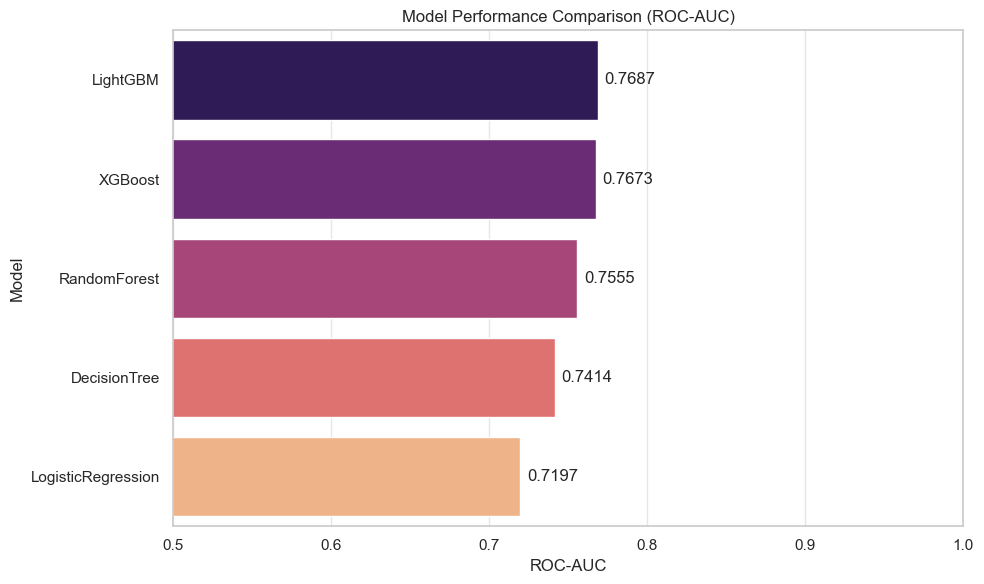

,Model,ROC-AUC
4,LightGBM,0.768726
3,XGBoost,0.767344
2,RandomForest,0.755521
1,DecisionTree,0.741394
0,LogisticRegression,0.719673


In [6]:
# Convert results to DataFrame for easier plotting and display
df_results = pd.DataFrame(list(results.items()), columns=['Model', 'ROC-AUC'])
df_results = df_results.sort_values(by='ROC-AUC', ascending=False)

# Visualize performance
plt.figure(figsize=(10, 6))
ax = sns.barplot(x='ROC-AUC', y='Model', data=df_results, palette='magma')
plt.title('Model Performance Comparison (ROC-AUC)')
plt.xlim(0.5, 1.0)

# Add value labels to the bars
for i in ax.containers:
    ax.bar_label(i, fmt='%.4f', padding=5)

plt.tight_layout()
os.makedirs("../results/figures", exist_ok=True)
plt.savefig("../results/figures/model_comparison.png")
plt.show()

display(df_results)


## 7. Save Fitted Models

All fitted models are persisted to the `models/` directory for use in the final evaluation stage.


In [ ]:
os.makedirs('../models', exist_ok=True)

for name, model in fitted_models.items():
    filepath = f'../models/{name.lower()}.pkl'
    joblib.dump(model, filepath)
    print(f'Saved: {filepath}')

print('\nAll models saved — ready for notebook 05_evaluation.')


## Final Summary

| Component | Strategy / Result |
|---|---|
| **Data Source** | Reduced feature set (top 100 features) from MI analysis |
| **Imbalance Handling** | Stratified weights (`scale_pos_weight` & `balanced`) |
| **Optimization** | Hyperparameter tuning via `RandomizedSearchCV` |
| **Evaluation Metric** | ROC-AUC (Primary indicator for training success) |
| **Model Persistence** | Individual `.pkl` files for all 5 classifiers |
| **Next Stage** | Full evaluation in `05_evaluation.ipynb` |

The fitted models are ready for detailed performance analysis, including confusion matrices and precision-recall curves.
